TokaMaker Meshing Example: Building an WHAM-like mesh {#doc_tMaker_mirror_ex1}
==========
In this example we show how to generate a mesh for an WHAM-like axisymmetric mirror using TokaMaker's built in mesh generation with Cubit as the backend.

**Warning:** Mirror equilibrium support is still in development. Please be careful when using this feature and report any issues.

**Note:** Running this example requires the [h5py](https://www.h5py.org/) python packages, which is installable using `pip` or other standard methods.

In [1]:
import os
import sys
import json
import h5py
import numpy as np
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=(6,6)
plt.rcParams['font.weight']='bold'
plt.rcParams['axes.labelweight']='bold'
plt.rcParams['lines.linewidth']=2
plt.rcParams['lines.markeredgewidth']=2
%matplotlib inline
%config InlineBackend.figure_format = "retina"

### Load TokaMaker library

To load the TokaMaker python module we need to tell python where to the module is located. This can be done either through the `PYTHONPATH` environment variable or using within a script using `sys.path.append()` as below, where we look for the environement variable `OFT_ROOTPATH` to provide the path to where the OpenFUSIONToolkit is installed (`/Applications/OFT` on macOS).

For meshing we will use the \ref OpenFUSIONToolkit.TokaMaker.gs_Domain "gs_Domain" class to build a 2D triangular grid suitable for Grad-Shafranov equilibria. This class uses the [triangle code](https://www.cs.cmu.edu/~quake/triangle.html) through a simple internal python wrapper within OFT.

In [2]:
tokamaker_python_path = os.getenv('OFT_ROOTPATH')
if tokamaker_python_path is not None:
    sys.path.append(os.path.join(tokamaker_python_path,'python'))
from OpenFUSIONToolkit.TokaMaker.meshing import gs_Domain, save_gs_mesh

# Build mesh

## Load geometry information
The geometry information (eg. bounding curves for vacuum vessel) are now loaded from a JSON file. For simple geometries, testing, or generative usage this can be created directly in the code. However, it is often helpful to separate this information into a fixed datafile as here. This JSON file contains the following:
 - `lim_con`: A contour of R,Z points defining the inner surface of the vacuum vessel

In [4]:
with open('WHAM_geom.json','r') as fid:
    WHAM_geom = json.load(fid)
lim_contour = np.array(WHAM_geom['lim_con'])

# Manually specify HTS coil info for now
HTS_Jmax = 602
HTS_A = np.array([85.6, 139.6, 225.2, 558.8])
HTS_rmin = np.array( [0.06, 0.087, 0.1269, 0.1885]) # m
HTS_dr = np.array( [0.0214, 0.0349, 0.0563, 0.1397] ) # m
HTS_z0 = 0.98
HTS_W = 0.0143*8

# Manually specify W7-A coil info for now
W7A_z0 = 0.20
W7A_dr, W7A_dz = 0.4, 0.183
W7A_r0 = 0.55 + 0.5*W7A_dr

## Split geometry to enable mesh packing
Here we do a simple sub-division of the limiter contour to enable packing of the grid resolution in the plasma as the radial size of the domain changes along the length of the mirror.

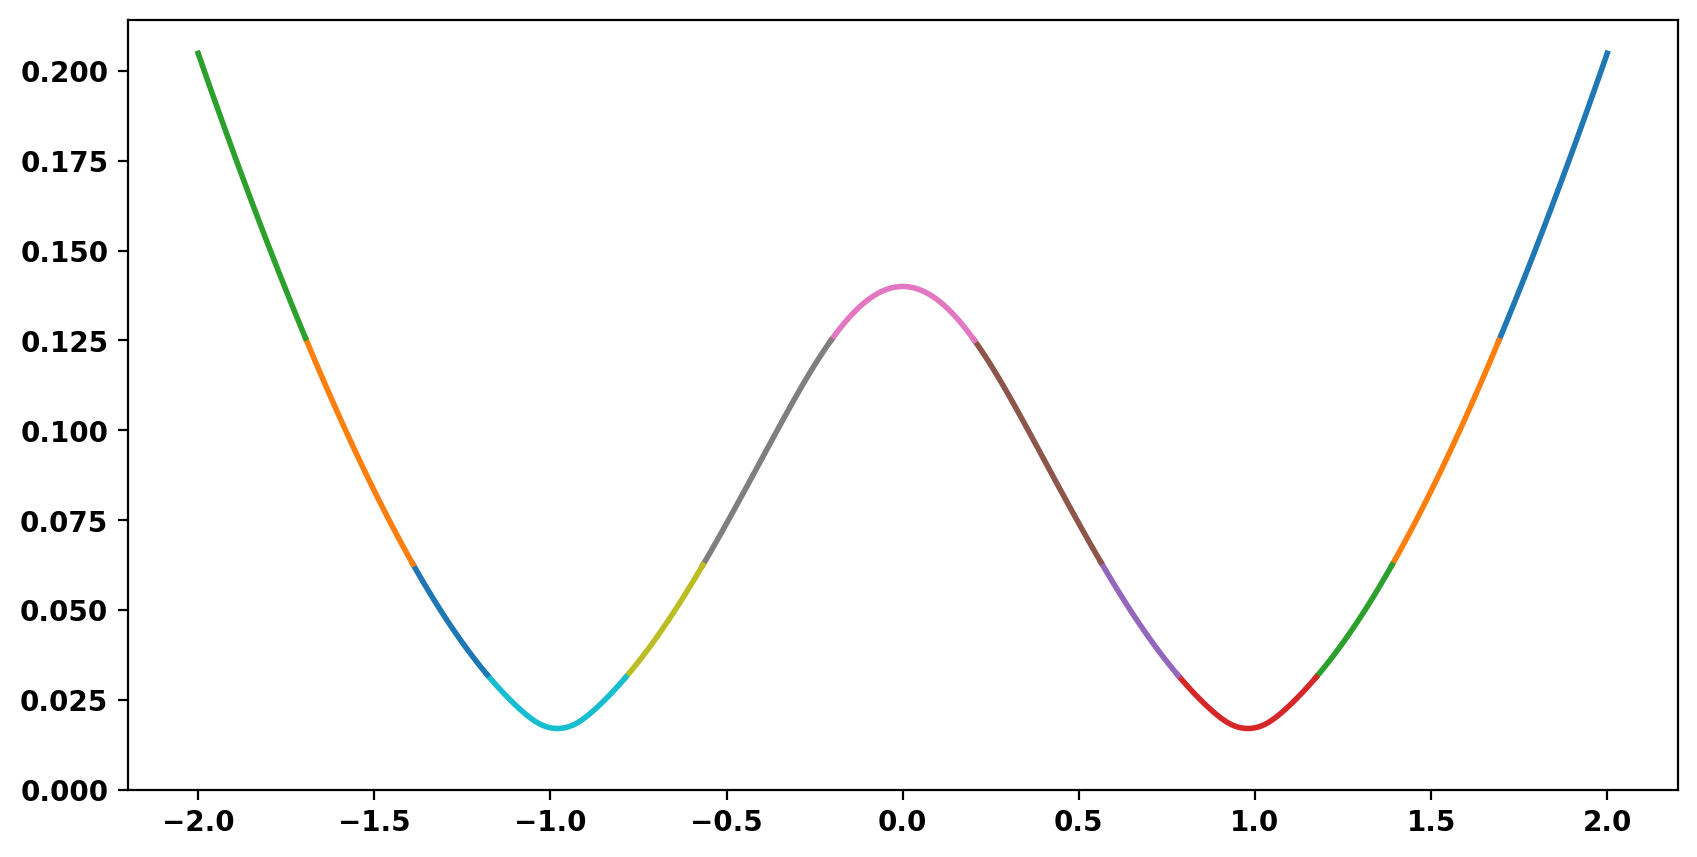

In [5]:
domain_curr = 0.125
domain_splits = []
domain_resfacs = [1.0]
down = True
for i in range(lim_contour.shape[0]-1):
    if lim_contour[i,1] < domain_curr/2.0 or (lim_contour[i+1,1] < domain_curr and lim_contour[i,1] >= domain_curr):
        domain_splits.append(lim_contour[i,0])
        domain_resfacs.append(domain_resfacs[-1]/2.0)
        domain_curr = domain_curr/2.0
    elif lim_contour[i,1] > domain_curr*2.0 or (lim_contour[i+1,1] > domain_curr and lim_contour[i,1] <= domain_curr):
        domain_splits.append(lim_contour[i,0])
        domain_resfacs.append(domain_resfacs[-1]*2.0)
        domain_curr = domain_curr*2.0

# Plot sub-divided limiter
fig, ax = plt.subplots(1,1,figsize=(10,5))
limiter_chunks = []
i0 = 0
for z0 in domain_splits:
    i1 = abs(lim_contour[:,0]-z0).argmin()
    limiter_chunks.append(lim_contour[i0:i1+1,:])
    ax.plot(lim_contour[i0:i1+1,0],lim_contour[i0:i1+1,1])
    i0 = i1
limiter_chunks.append(lim_contour[i0:,:])
ax.plot(lim_contour[i0:,0],lim_contour[i0:,1])
_ = ax.set_ylim(bottom=0.0)

## Define regions and attributes
We now create and define the various logical mesh regions. In the WHAM case we have 3 types of regions:
 - `air`: The region outside the vacuum vessel
 - `plasma`: The region inside the limiter (vacuum vessel) where the plasma will exist. *Note:* multiple regions are defined for packing, but will be combined to a single logical region after meshing.
 - `mirrorLX, ...`: Each of the mirror and central cell coils

For each region you can provide a target size and one of four region types:
 - `plasma`: The region where the plasma can exist and the classic Grad-Shafranov equation with $F*F'$ and $P'$ are allowed. **All regions of this type must be connected to form a single region**
 - `vacuum`: A region where no current can flow and $\nabla^* \psi = 0$ is solved
 - `boundary`: A special case of the `vacuum` region, which forms the outer boundary of the computational domain. **A region of this type is required if more than one region is specified**
 - `conductor`: A region where toroidal current can flow passively (no externally applied voltage). For this type of region the resistivity should be specified with the argument `eta` in units of $\omega \mathrm{-m}$.
 - `coil`: A region where toroidal current can flow with specified amplitude through \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.set_coil_currents "set_coil_currents()" or via shape optimization \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.set_coil_reg "set_coil_reg()" and \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.set_isoflux "set_isoflux()"

In [5]:
# Define base mesh resolution
mesh_dx = 0.01
# Create a G-S domain
gs_mesh = gs_Domain()
# Define region information for mesh
for i, _ in enumerate(limiter_chunks):
    gs_mesh.define_region('plasma{0}'.format(i+1),mesh_dx*domain_resfacs[i],'plasma')
gs_mesh.define_region('air',mesh_dx*8.0,'boundary')
for i in range(4):
    gs_mesh.define_region('mirrorL{0}'.format(i+1),mesh_dx*2.0,'coil',coil_set='mirror',nTurns=HTS_A[i]*HTS_Jmax*8)
    gs_mesh.define_region('mirrorR{0}'.format(i+1),mesh_dx*2.0,'coil',coil_set='mirror',nTurns=HTS_A[i]*HTS_Jmax*8)
gs_mesh.define_region('central1',mesh_dx*2.0,'coil',coil_set='central',nTurns=12)
gs_mesh.define_region('central2',mesh_dx*2.0,'coil',coil_set='central',nTurns=12)

## Define geometry for region boundaries
Once the region types and properties are defined we now define the geometry of the mesh using shapes and references to the defined regions.
 1. We add polygons for each of the plasma sub-regions with higher resolution near the mirror coils.
 2. We add each of the sub-coils for the mirror and central coils as "rectangles", which are defined by a center point (R,Z) along with a width (W) and height (H).
 3. We manually specify a boundary contour to ensure handling of region overlaps at R=0 (will be handled automatically in the future).

In [6]:
# Add limiter contour
plasma_axis = []
for i, limiter_chunk in enumerate(limiter_chunks):
    plasma_boundary = np.zeros((limiter_chunk.shape[0]+2,2))
    plasma_boundary[1:-1,:] = limiter_chunk[:,[1,0]]
    plasma_boundary[0,1] = plasma_boundary[1,1]
    plasma_boundary[-1,1] = plasma_boundary[-2,1]
    gs_mesh.add_polygon(plasma_boundary,'plasma{0}'.format(i+1))
    plasma_axis.append(plasma_boundary[0,:])
plasma_axis.append(plasma_boundary[-1,:])
plasma_axis = np.array(plasma_axis)

# Add coils
for i in range(4):
    gs_mesh.add_rectangle(HTS_rmin[i]+HTS_dr[i]/2.0,-HTS_z0,HTS_dr[i],HTS_W,'mirrorL{0}'.format(i+1))
    gs_mesh.add_rectangle(HTS_rmin[i]+HTS_dr[i]/2.0,HTS_z0,HTS_dr[i],HTS_W,'mirrorR{0}'.format(i+1))
gs_mesh.add_rectangle(W7A_r0,-W7A_z0,W7A_dr,W7A_dz,'central1')
gs_mesh.add_rectangle(W7A_r0,W7A_z0,W7A_dr,W7A_dz,'central2')

# Add outer mesh boundary (must define for now as other regions intersect R=0)
Rmax = (W7A_r0 + W7A_dr)*1.1
boundary_path = np.array([
    [0.0, -2.5], [Rmax, -2.5],
    [Rmax, 2.5], [0.0, 2.5],
    [0.0, -2.5]
])
gs_mesh.add_polygon(boundary_path,'air')

## Plot topology
After defining the logical and physical topology we can now plot the curves within the definitions to double check everything is in the right place.

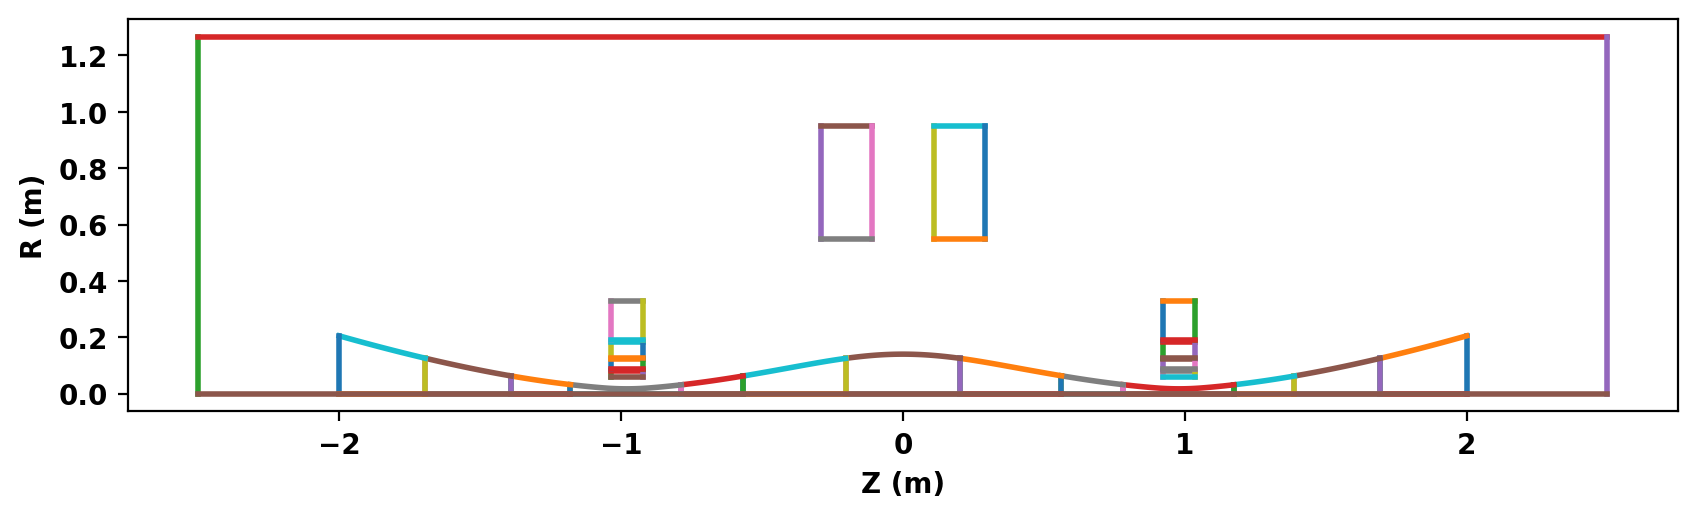

In [7]:
fig, ax = plt.subplots(1,1,figsize=(10,5))
gs_mesh.plot_topology(fig,ax,rotate=True)

## Generate mesh using Cubit
Now we generate the actual mesh using the \ref OpenFUSIONToolkit.TokaMaker.gs_Domain.build_mesh "build_mesh()" method. Additionally, as `coil` and/or `conductor` regions are defined the \ref OpenFUSIONToolkit.TokaMaker.gs_Domain.get_coils "get_coils()" and \ref OpenFUSIONToolkit.TokaMaker.gs_Domain.get_conductors "get_conductors()" methods are also be called to get descriptive dictionaries for later use in TokaMaker.

To generate a higher quality mesh with grid packing we utilize the Cubit code as the mesh generation backend. To do this we must specify the full path to the Cubit executable, which is shown for the default install path on macOS here.

Note that, as is common with unstructured meshes, the mesh is stored a list of points `mesh_pts` of size (np,2), a list of cells formed from three points each `mesh_lc` of size (nc,3), and an array providing a region id number for each cell `mesh_reg` of size (nc,), which is mapped to the names above using the `coil_dict` and `cond_dict` dictionaries.

In [8]:
mesh_pts, mesh_lc, mesh_reg = gs_mesh.build_mesh(cubit_path='/Applications/Cubit-16.18/Cubit.app/Contents/MacOS/cubit')#,cubit_gradation=1.1)
coil_dict = gs_mesh.get_coils()
cond_dict = gs_mesh.get_conductors()

Generating mesh with Cubit:
    Executive Exodus summary:
      Number of dimensions     = 3
      Number of element blocks = 12
      Number of sidesets       = 0
      Number of nodesets       = 0
      Number of bc sets        = 1
      Number of elements       = 21392
      Number of nodes          = 10950
    
Converting mesh to native format:
    Reading mesh: tMaker_cubit.g
      Mesh type    = TRI_p1
      Dimension    = 2
      # of points  = 10950 (0)
      # of cells   = 21392
      # of regions = 12
      # of nSets   = 0
      # of sSets   = 0
    Saving mesh: tMaker_cubit.h5


## Plot resulting regions and grid
We now plot the mesh by region to inspect proper generation.

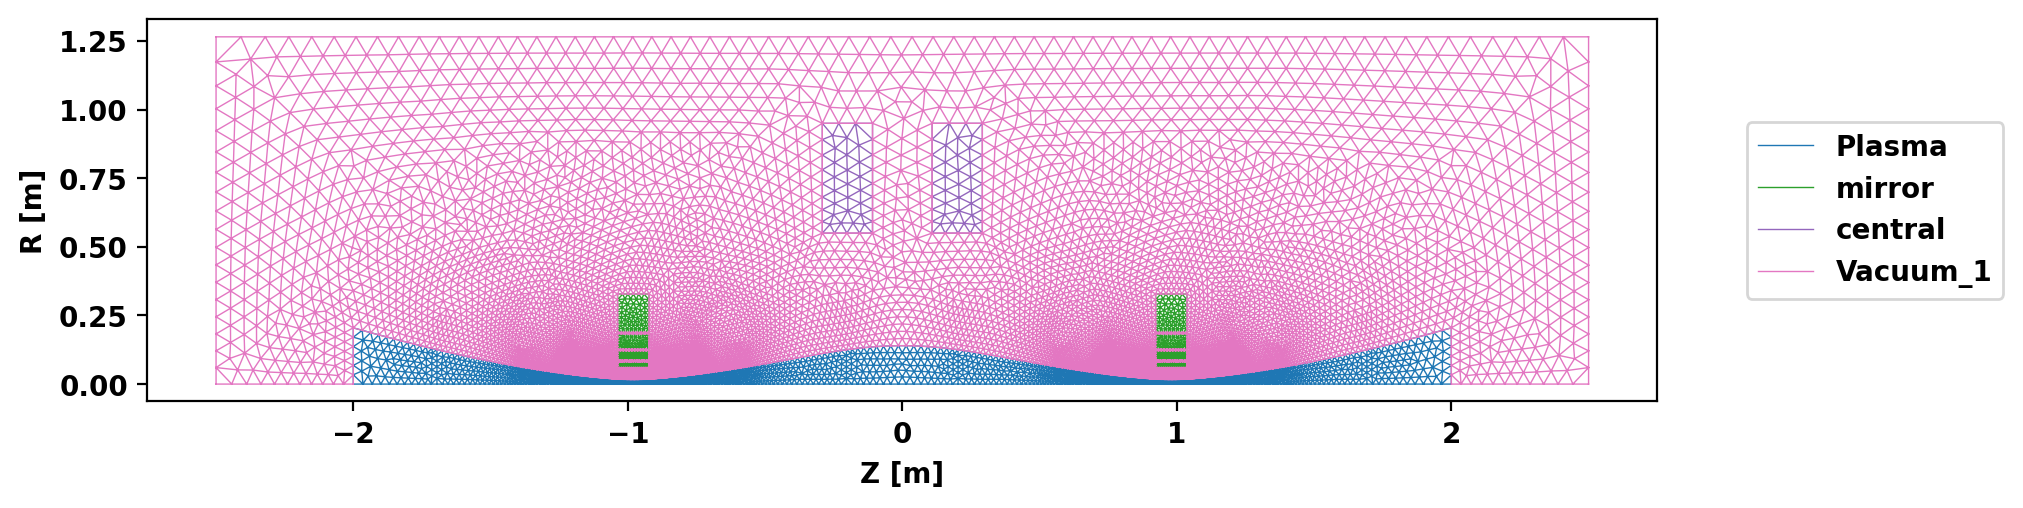

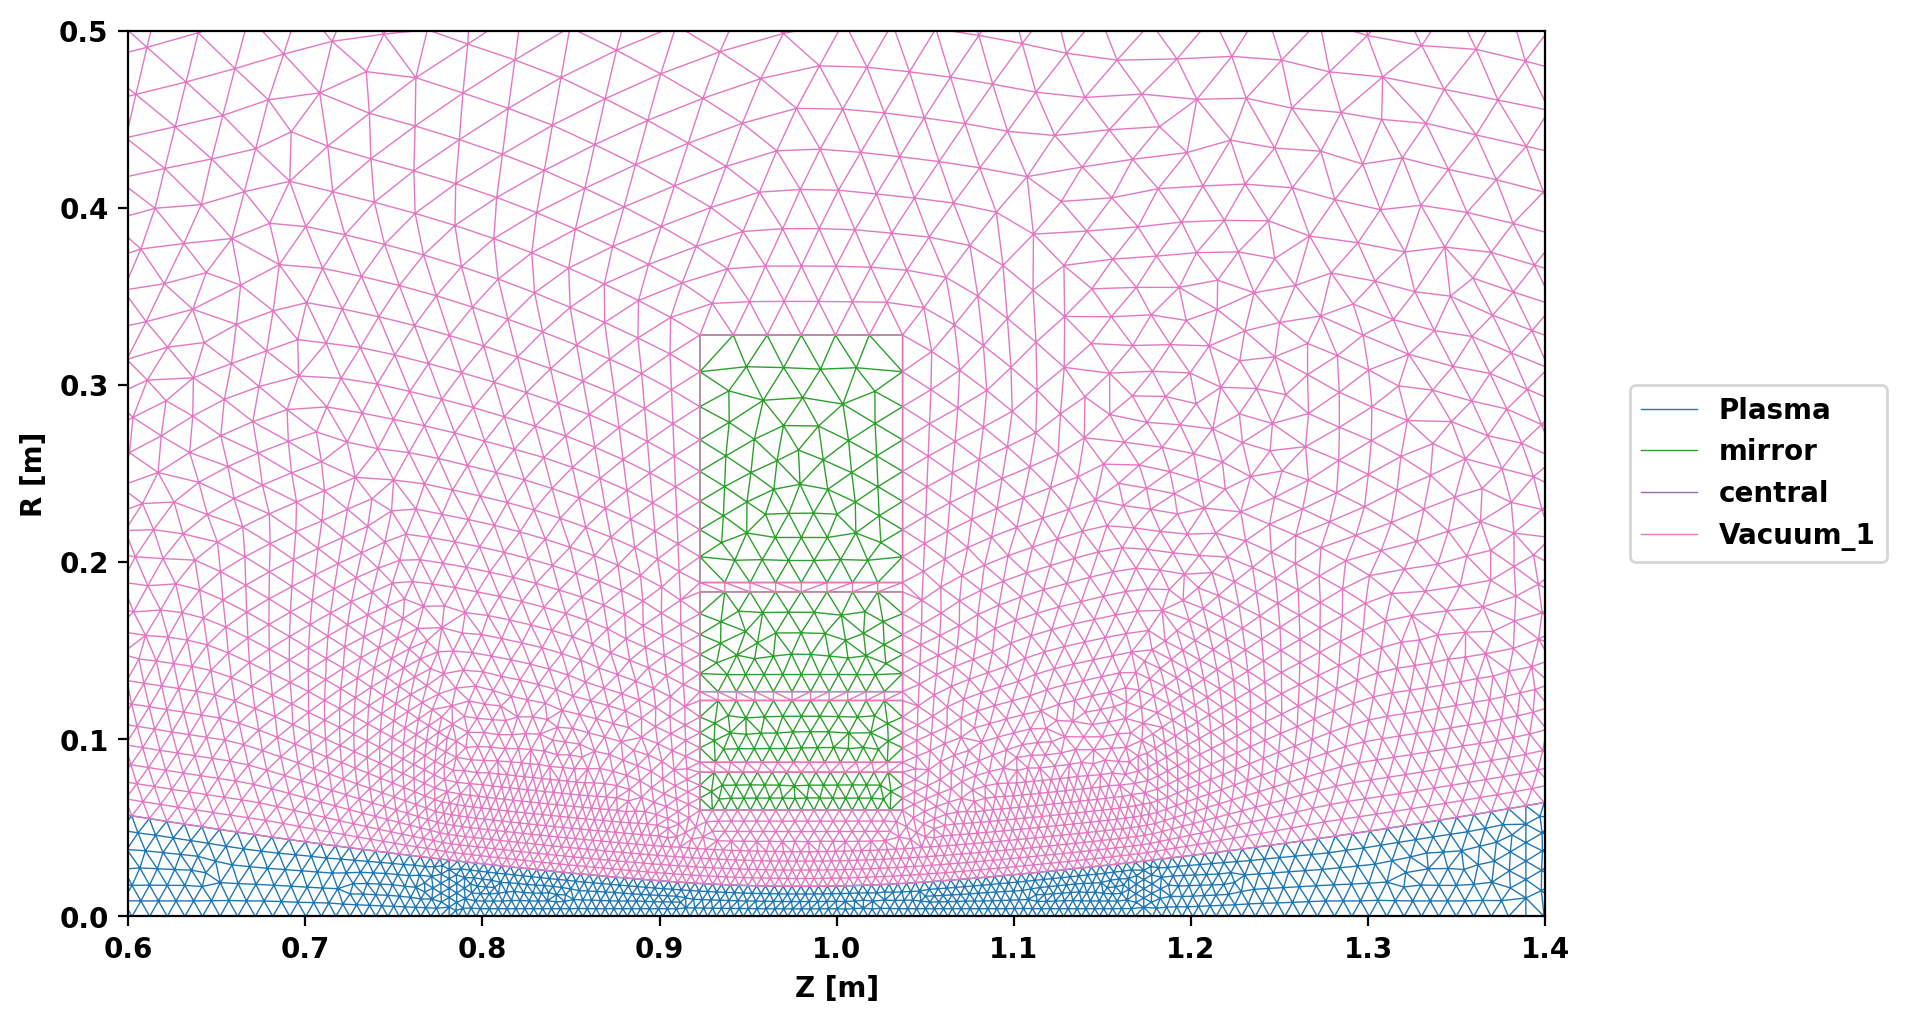

In [9]:
fig, ax = plt.subplots(1,1,figsize=(10,5),constrained_layout=True)
gs_mesh.plot_mesh(fig,ax,rotate=True)
ax.set_xlabel('Z [m]')
_ = ax.set_ylabel('R [m]')

fig, ax = plt.subplots(1,1,figsize=(10,5),constrained_layout=True)
gs_mesh.plot_mesh(fig,ax,rotate=True)
ax.set_ylim(0.0,0.5)
ax.set_xlim(0.6,1.4)
ax.set_xlabel('Z [m]')
_ = ax.set_ylabel('R [m]')

## Save mesh for later use
As generation of the mesh often takes comparable, or longer, time compare to runs in TokaMaker it is useful to separate generation of the mesh into a different script as demonstrated here. The method \ref OpenFUSIONToolkit.TokaMaker.save_gs_mesh "save_gs_mesh()" can be used to save the resulting information for later use. This is done using and an [HDF5](https://www.hdfgroup.org/solutions/hdf5/) file through the [h5py](https://www.h5py.org/) library.

In [10]:
save_gs_mesh(mesh_pts,mesh_lc,mesh_reg,coil_dict,cond_dict,'WHAM_mesh-new.h5')